In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
 

In [14]:
# Load the Breast Cancer Wisconsin dataset

data = load_breast_cancer()

print("Dataset loaded successfully!")
print("Number of samples:", data.data.shape[0])
print("Number of features:", data.data.shape[1])

Dataset loaded successfully!
Number of samples: 569
Number of features: 30


In [15]:
# Create a pandas DataFrame

classification_df = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

# Add the target column
classification_df["target"] = data.target

# Display the first 5 rows
classification_df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [16]:
# Display basic information about the dataset

print("Dataset shape:")
print(classification_df.shape)

print("\nDataset information:")
classification_df.info()

Dataset shape:
(569, 31)

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    flo

In [17]:
# Display statistical summary

classification_df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [18]:
# Check for missing values

print("Missing values in each column:")
print(classification_df.isnull().sum())

Missing values in each column:
mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64


In [19]:
# Display target classes

print("Target values:")
print(classification_df["target"].unique())

print("\nTarget value counts:")
print(classification_df["target"].value_counts())

print("\nTarget names:")
print(data.target_names)

Target values:
[0 1]

Target value counts:
target
1    357
0    212
Name: count, dtype: int64

Target names:
['malignant' 'benign']


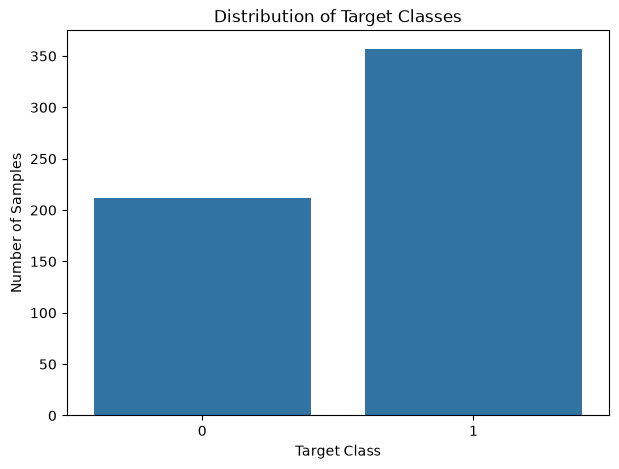

In [20]:
# Visualize the distribution of the target classes

plt.figure(figsize=(7, 5))

sns.countplot(
    x="target",
    data=classification_df
)

plt.title("Distribution of Target Classes")
plt.xlabel("Target Class")
plt.ylabel("Number of Samples")

plt.show()

In [21]:
# Separate input features (X) and target (y)

X = classification_df.drop("target", axis=1)

y = classification_df["target"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (569, 30)
Target shape: (569,)


In [22]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (455, 30)
Testing features: (114, 30)
Training target: (455,)
Testing target: (114,)


In [23]:
# Create the StandardScaler

scaler = StandardScaler()

# Fit the scaler only on the training data
X_train_scaled = scaler.fit_transform(X_train)

# Apply the same scaler to the test data
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed!")
print("Scaled training data shape:", X_train_scaled.shape)
print("Scaled testing data shape:", X_test_scaled.shape)

Feature scaling completed!
Scaled training data shape: (455, 30)
Scaled testing data shape: (114, 30)


In [24]:
# Create the Logistic Regression model

log_model = LogisticRegression(
    max_iter=1000
)

print("Logistic Regression model created successfully!")

Logistic Regression model created successfully!


In [25]:
# Train the Logistic Regression model

log_model.fit(
    X_train_scaled,
    y_train
)

print("Model training completed successfully!")

Model training completed successfully!


In [26]:
# Make predictions on the test data

y_pred = log_model.predict(X_test_scaled)

print("Predictions generated successfully!")

print("\nFirst 10 predictions:")
print(y_pred[:10])

Predictions generated successfully!

First 10 predictions:
[0 1 0 1 0 1 1 0 0 0]


In [27]:
# Compare actual values with predicted values

comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,0,0
1,1,1
2,0,0
3,1,1
4,0,0
5,1,1
6,1,1
7,0,0
8,0,0
9,0,0


In [28]:
# Calculate model accuracy

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)
print("Accuracy percentage:", accuracy * 100, "%")

Accuracy: 0.9824561403508771
Accuracy percentage: 98.24561403508771 %


In [29]:
# Generate the classification report

print("Classification Report:")
print()

print(
    classification_report(
        y_test,
        y_pred,
        target_names=data.target_names
    )
)

Classification Report:

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [30]:
# Calculate the confusion matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[41  1]
 [ 1 71]]


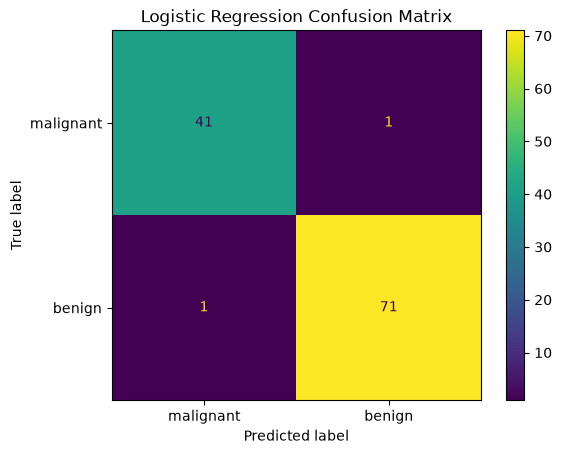

In [31]:
# Display the confusion matrix visually

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=data.target_names
)

display.plot()

plt.title("Logistic Regression Confusion Matrix")

plt.show()

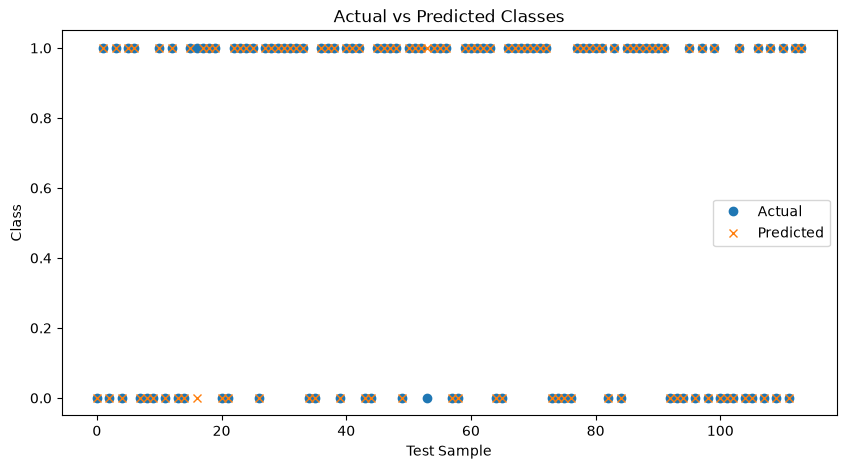

In [32]:
# Visual comparison of actual and predicted classes

plt.figure(figsize=(10, 5))

plt.plot(
    range(len(y_test)),
    y_test.values,
    label="Actual",
    marker="o",
    linestyle=""
)

plt.plot(
    range(len(y_pred)),
    y_pred,
    label="Predicted",
    marker="x",
    linestyle=""
)

plt.xlabel("Test Sample")
plt.ylabel("Class")
plt.title("Actual vs Predicted Classes")

plt.legend()

plt.show()

In [33]:
# Display Logistic Regression coefficients

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": log_model.coef_[0]
})

coefficients["Absolute_Coefficient"] = (
    coefficients["Coefficient"].abs()
)

coefficients = coefficients.sort_values(
    by="Absolute_Coefficient",
    ascending=False
)

coefficients.head(10)

,Feature,Coefficient,Absolute_Coefficient
21,worst texture,-1.255088,1.255088
10,radius error,-1.082965,1.082965
27,worst concave points,-0.953686,0.953686
23,worst area,-0.947756,0.947756
20,worst radius,-0.947616,0.947616
28,worst symmetry,-0.939181,0.939181
13,area error,-0.929104,0.929104
26,worst concavity,-0.823151,0.823151
22,worst perimeter,-0.763220,0.763220
24,worst smoothness,-0.746625,0.746625
